<a href="https://colab.research.google.com/github/Diego-LeivaC/market-leiva/blob/main/market-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The following notebook describes....

## **Data Loading**

In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "xxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxx"
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows


Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
!unzip *.zip

Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
replace imdb_top_1000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: imdb_top_1000.csv       


In [3]:
import pandas as pd

data = pd.read_csv("imdb_top_1000.csv")
data.head(3)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


# **Data Analysis and Preprocessing**

In [ ]:
data.shape

There are 1000 rows (1000 films) and 16 columns.

In [ ]:
data.columns

The column 'Series_Title' refers to the film's name.

In [ ]:
data['Series_Title'].isnull().sum()

All films are completed.

The columns: 'Star1', 'Star2', 'Star3', 'Star4' are the actor names.

In [ ]:
data[['Star1','Star2','Star3','Star4']].isnull().sum()

All actors are completed.

In [ ]:
data = data.drop_duplicates()
data.shape

There are no duplicates.

In [4]:
for col in ["Star1","Star2","Star3","Star4"]:
    data[col] = data[col].str.strip().str.lower()

To uniformize the actor's names, those are without spance and in lowercase.



# **The Market-Basket Model**

*"The market-basket model of data is used to describe a common form of many
many relationship between two kinds of objects. On the one hand, we have
items, and on the other we have baskets, sometimes called “transactions.”
Each basket consists of a set of items (an itemset), and usually we assume that
the number of items in a basket is small– much smaller than the total number
of items. The numbe *testo in corsivo*r of baskets is usually assumed to be very large, bigger than what can fit in main memory."* (book 6.1)

Considering that each film is to be considered a basket, and actors listed under the Star1, Star2, Star3 and Star4 fields as items. I transform each film in a list of actors.

In [5]:
transactions = data[['Star1','Star2','Star3','Star4']].values.tolist()

In [6]:
import random
print(random.sample(transactions, 2))

[['johnny depp', 'martin landau', 'sarah jessica parker', 'patricia arquette'], ['charlton heston', 'orson welles', 'janet leigh', 'joseph calleia']]


The attribute transactions is a market-basket format.

Before passing the A-priori algorithm, considered these concepts associated with the project:

*   Itemset Size ($k$): Represents the number of items contained within a specific candidate or frequent set during a given iteration. For this project, $k$ defines the number of actors being analyzed in a combination, where the algorithm progresses from individual actors ($k=1$) to pairs ($k=2$), triples ($k=3$), until $k=4$.

*   Support Threshold ($s$): Is the minimum frequency that an itemset must reach to be considered significant and "frequent". In this context, $s$ determines the minimum number of movies in which a group of actors must appear together for their relationship to be identified as a pattern.





# **A-priori Algorithm for All Frequent Itemset**

*"In the A-Priori Algorithm, one pass is taken for each set-size k. If no frequent
itemsets of a certain size are found, then monotonicity tells us there can be no
larger frequent itemsets, so we can stop.
The pattern of moving from one size k to the next size k + 1 can be summarized as follows. For each size k, there are two sets of itemsets: Ck is the set of candidate itemsets of size k– the itemsets that we must
count in order to determine whether they are in fact frequent. Lk is the set of truly frequent itemsets of size k."*(book 15)

In practice, the mlxtend library runs the full A-Priori algorithm. This algorithm operates through iterative cycles (multiple passes):



* Pass 1: Finds frequent individual items ($L_1$) who appear in more than $s$ films, where $s$ is the support threshold.


*   Pass 2: Combines items from the previous step to find frequent pairs ($L_2$).

*   Pass 3: Takes the frequent pairs from step 2 and combines them to try to form candidate triplets ($C_3$). If those triplets exceed the minimum support, they become frequent triplets ($L_3$).

*   Pass 4: Generates candidate quadruplets ($C_4$). This is the maximum limit. The algorithm will attempt to see whether there are 4 actors who always appear together in the 4 columns in a film.

End of the Algorithm: The algorithm stops because there is no basket with 5 actors, so the support of any quintuplet would automatically be 0.


In [7]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# Creates an object that can transform data (actor names) to a mathematic format.
transaction_encoder = TransactionEncoder()

# Convert the variable "transactions", transforming it into a boolean matrix False/True.
te_array = transaction_encoder.fit(transactions).transform(transactions)

# Convert the matrix into a table
data_encoded = pd.DataFrame(te_array, columns=transaction_encoder.columns_)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
data_encoded.head(3)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,aamir bashir,aamir khan,aaron eckhart,aaron taylor-johnson,abdel ahmed ghili,abhay deol,abigail breslin,abraham attah,adam baldwin,adam driver,...,ziyi zhang,zoe saldana,zooey deschanel,zoë kravitz,álvaro guerrero,çetin tekindor,émile vallée,éric toledano,ömer faruk sorak,özge özberk
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Interpretation:**

"True" means that the actor appears in the film, "False" means that not. For instance, among the 2709 actors, Aaron Eckhart was the star 3 of the film The Dark Knight, this film was in the row 2 on the original dataset.

*"After the first pass, we examine the counts of the items to determine which of them are frequent as singletons. It might appear surprising that many singletons are not frequent. But remember that we set the threshold s sufficiently high that we do not get too many frequent sets; a typical s would be 1% of the baskets."* (book 14)

In [9]:
frequent_combinations = apriori(data_encoded, min_support=0.01, use_colnames=True)
frequent_combinations.shape

(9, 2)

In [10]:
# Orders by frequency, most frequent actors of the dataset, to see also the maximun support
frequent_combinations.sort_values("support", ascending=False).head(9)

,support,itemsets
7,0.017,(robert de niro)
8,0.014,(tom hanks)
0,0.013,(al pacino)
1,0.012,(brad pitt)
3,0.012,(clint eastwood)
6,0.011,(matt damon)
2,0.011,(christian bale)
5,0.011,(leonardo dicaprio)
4,0.010,(james stewart)


**Interpretation:**

The maximum support threshold is 0.017.
Robert De Niro appears in 1.7% of films, meaning that De Niro appears in 17 of the 1000 films in the dataset. The same logic applies to the rest of actors.

Testing different support threshold

In [11]:
supports = [0.017, 0.005, 0.002, 0.0012]

results = []
for s in supports:
    res = apriori(data_encoded, min_support=s, use_colnames=True)
    results.append((s, len(res)))

pd.DataFrame(results, columns=["support","num_itemsets"])

,support,num_itemsets
0,0.0170,1
1,0.0050,83
2,0.0020,791
3,0.0012,791


**Interpretation:**

As expected only one itemset (Robert De Niro) has the support 0.017, as the support threshold decreases the number of itemsets increases, where 0.0020 and 0.0012 have the same number since 1.2 films is equivalent to 2 films because the algorihm works with whole numbers.
From now on 0.002 is considered the lowest support with 791 itemsets.

# **Main memory limitation**

When the support threshold was lowered to 0.001, the algorithm failed due to memory limitations with this message: "The session crashed because all available RAM was used".
With support=0.001, the algorithm returns all itemsets that appear in at least 1 film and that involves practically every possible combination of actors.

To find the frequent pairs, the algorithm follows these steps according to the theory:

*   Step 1: Identify frequent items ($L_1$): First, it finds which actors appear in more than $s$ films. With $s=0.001$, all 2,709 actors are considered frequent.

*   Step 2: Generate Candidates ($C_2$): This is where the memory disaster could occurs. The algorithm generates all possible combinations of the frequent actors to create a data structure where it will accumulate the counts.


*   Combinatorial Analysis: Since the actors are represented as columns (2,709 columns), A-Priori generates the combination of every column with one another. This means $\binom{2709}{2} \approx 3.6$ million candidate pairs (exactly 3,667,986 pairs). For k=3 and k=4 the candidate pairs are also higher.



# **Analysis of Multi-Actor Itemsets ($k \geq 2$) with $s=0.002$**

The next code block filters the results to show combinations of two or more actors, reducing the support threshold to 0.002 (which means it's enough that they've appeared together in 2 films)

In [12]:
frequent_combinations = apriori(data_encoded, min_support=0.002, use_colnames=True)

# Creation of a column with the length of each combination
frequent_combinations['length'] = frequent_combinations['itemsets'].apply(lambda x: len(x))

# Filter to show only combinations of 2 or more actors and displayed the best.
frequent_combinations[frequent_combinations['length'] >= 2].sort_values("support", ascending=False).head()

,support,itemsets,length
689,0.006,"(rupert grint, daniel radcliffe)",2
687,0.005,"(emma watson, daniel radcliffe)",2
774,0.005,"(rupert grint, emma watson, daniel radcliffe)",3
701,0.005,"(rupert grint, emma watson)",2
723,0.004,"(robert de niro, joe pesci)",2


**Interpretation:**

The maximum support is 0.006, corresponding to Daniel Radcliffe and Rupert Grind, it means that they appeared together in 6 films. It is present a length 3 with support 0.005 to the same previous actors and Emma Watson. This trio happened automatically because in Pass 2, the algorithm noticed that:


*   Daniel and Rupert are a frequent pair (6 movies).

*   Daniel and Emma are a frequent pair (5 movies).


*   Rupert and Emma are a frequent pair (5 movies).

Since all subsets were frequent, A-Priori generated the 3-actor candidate in its third pass and confirmed that they do, in fact, exceed the 0.002 threshold.

In [13]:
frequent_combinations[frequent_combinations['length'] >= 4].sort_values("support", ascending=False).head()

,support,itemsets,length
787,0.002,"(billy dee williams, carrie fisher, mark hamil...",4
788,0.002,"(rupert grint, emma watson, michael gambon, da...",4
789,0.002,"(david carradine, uma thurman, daryl hannah, m...",4
790,0.002,"(elijah wood, orlando bloom, ian mckellen, vig...",4


In [14]:
frequent_combinations[frequent_combinations['length'] >= 5].shape

(0, 3)

As expected the maximum combinations are with length 4, there are no combinations with length equal o higher than 5. After identifying frequent itemsets of actors using Apriori, it is retrieved the corresponding films by filtering the original dataset and selecting only records containing the actors of the itemset.

In [15]:
target_stars = ['viggo mortensen', 'elijah wood', 'ian mckellen', 'orlando bloom']
cols = ['Star1','Star2','Star3','Star4']
result = data[data[cols].apply(lambda r: set(target_stars).issubset(set(r)), axis=1)]
result[['Series_Title'] + cols]

,Series_Title,Star1,Star2,Star3,Star4
5,The Lord of the Rings: The Return of the King,elijah wood,viggo mortensen,ian mckellen,orlando bloom
13,The Lord of the Rings: The Two Towers,elijah wood,ian mckellen,viggo mortensen,orlando bloom


The itemset of the above mentioned actors are consireded in exactly 2 films of The Lord of the Rings.

# **Generating Association Rules**

Until now the central concept is about the support (s) that is applied over Itemsets (ej: {Robert De Niro, Joe Pesci}), and answers the question: How common is this group?
The next central concept is Confidence (c) that is applied over implications (ej: Robert De Niro -> Joe Pesci), and answers the quesion: How reliable is this relationship?

Considered these concepts associated with the project:
*   Confidence: The fraction of films containing actor A (I) that also contain actor B (j).
$$\text{confidence}(I \rightarrow j) = \frac{\text{support}(I \cup \{j\})}{\text{support}(I)}$$

*   Lift (Interest): How much more likely B is to appear given that A is present, compared to B's overall popularity.









In [16]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules based on a minimum confidence threshold with 0.50 (50%) to ensure the rules have a fairly high confidence
rules = association_rules(frequent_combinations, metric="confidence", min_threshold=0.50)

# Sort the rules by 'lift' (interest) and then by 'confidence' to see the strongest relationships first
rules_sorted = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

# Display the top 4 most interesting rules
rules_sorted.head(4)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(nikolay grinko),(anatoliy solonitsyn),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
5,(anatoliy solonitsyn),(nikolay grinko),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
6,(andré ramiro),(milhem cortaz),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
7,(milhem cortaz),(andré ramiro),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0


In [17]:
rules_sorted.shape

(337, 14)

*"The form of an association rule is I → j, where I is a set of items
and j is an item. The implication of this association rule is that if all of the
items in I appear in some basket, then j is “likely” to appear in that basket as
well."* (book 6.1.3)

**Interpretation:**

The first three rules show a Confidence of 1.0 and a very high Lift of 500. Anatoliy Solonitsyn -> Nikolay Grinko: This rule has 100% confidence. This means that in every single film in this dataset where Anatoliy Solonitsyn (I) appears, Nikolay Grinko (j) is also present. These rules have a Lift of 500. Significance: A high lift (interest) indicates that these actors are not just popular individually, but that their presence is heavily "caused" by or correlated with the other.

In [18]:
rules_sorted.tail(4)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
119,(joe russo),(scarlett johansson),0.004,0.009,0.002,0.500000,55.555556,1.0,0.001964,1.982,0.985944,0.181818,0.495459,0.361111
95,(franka potente),(matt damon),0.004,0.011,0.002,0.500000,45.454545,1.0,0.001956,1.978,0.981928,0.153846,0.494439,0.340909
116,(joe pesci),(robert de niro),0.006,0.017,0.004,0.666667,39.215686,1.0,0.003898,2.949,0.980382,0.210526,0.660902,0.450980
2,(diane keaton),(al pacino),0.006,0.013,0.003,0.500000,38.461538,1.0,0.002922,1.974,0.979879,0.187500,0.493414,0.365385


**Interpretation:**

Joe Pesci -> Robert De Niro: This rule has a Confidence of 0.666667. This implies that if Joe Pesci is in the movie, there is a 66.66 chance that Robert De Niro is also in it. Chris Evans -> Scarlett Johansson: This rule has a Confidence of 0.50. This means that in half of the movies where Chris Evans appears, Scarlett Johansson is also a "Star" in the basket. Notice that the lift here is lower (around 39.2 to 55.5) compared to the 500.0 at the top list. This is because Robert De Niro and Scarlett Johansson are very frequent items on their own. Since they appear in many movies, the "surprise" of finding them with a specific partner is mathematically lower than with less frequent actors.

**First Conclusion:**


* The Apriori algorithm successfully extracted frequent actor combinations and meaningful association rules from the dataset. The experiment demonstrated both the practical applicability of frequent pattern mining and the importance of parameter tuning, particularly the support threshold, for obtaining informative results. Although Apriori is effective for discovering frequent itemsets, it requires multiple passes over the dataset and can become computationally expensive as the number of items increases or when the support threshold is the minimum. Those limitations motivates the use of more scalable algorithms such as SON or Toivonen's Algorithm, which will be explored as follows.





# **SON Algorithm**

Instead of processing the entire dataset at once, SON (Savasere–Omiecinski–Navathe) algorithm divides the data into smaller chunks and runs a frequent itemset algorithm on each partition using a reduced support threshold. As described in the literature, “the idea is to divide the input file into chunks… and run the algorithm on that chunk” (Book 6.4.3).

"Once all the chunks have been processed in that way, take the union of
all the itemsets that have been found frequent for one or more chunks. These
are the candidate itemsets".(6.4.3)

"Every itemset that is frequent in the whole is frequent in
at least one chunk, and we can be sure that all the truly frequent itemsets are
among the candidates; i.e., there are no false negatives.
We have made a total of one pass through the data as we read each chunk
and processed it. In a second pass, we count all the candidate itemsets and
select those that have support at least s as the frequent itemsets"


In [22]:
import math

def SON(data_encoded, support, chunks=4):

    chunk_size = math.ceil(len(data_encoded)/chunks)
    candidates = set()

    # PASS 1 — local frequent itemsets
    for i in range(0, len(data_encoded), chunk_size):

        chunk = data_encoded.iloc[i:i+chunk_size]

        reduced_support = support * (len(chunk)/len(data_encoded))

        freq = apriori(chunk, min_support=reduced_support, use_colnames=True)

        for itemset in freq["itemsets"]:
            candidates.add(frozenset(itemset))

    # PASS 2 — count candidates globally
    candidate_list = list(candidates)

    counts = {c:0 for c in candidate_list}

    for _, row in data_encoded.iterrows():
        basket = set(data_encoded.columns[row])
        for cand in candidate_list:
            if cand.issubset(basket):
                counts[cand]+=1

    # final frequent
    final = []
    for cand,count in counts.items():
        if count/len(data_encoded) >= support:
            final.append((cand,count/len(data_encoded)))

    return pd.DataFrame(final, columns=["itemsets","support"])

In [23]:
SON_results = SON(data_encoded, support=0.002, chunks=4)
SON_results.sort_values("support", ascending=False).head()

,itemsets,support
318,(robert de niro),0.017
243,(tom hanks),0.014
155,(al pacino),0.013
204,(brad pitt),0.012
230,(clint eastwood),0.012


In [24]:
SON_results.shape

(791, 2)

Similar to A-priori, at support 0.002 SON has 791 itemsets, but in this case there's is no memory crash when the threshold is 0.001, with the following result:

In [25]:
SON_results = SON(data_encoded, support=0.001, chunks=4)
SON_results.sort_values("support", ascending=False).tail()

,itemsets,support
4639,"(chloë grace moretz, nicolas cage)",0.001
4640,"(adel bencherif, reda kateb, niels arestrup)",0.001
4641,"(rock hudson, james dean)",0.001
4642,(kari sylwan),0.001
4630,"(lillo brancato, chazz palminteri)",0.001


In [26]:
SON_results.shape

(13492, 2)

**Interpretation:**

A-priori fails at support s=0.001 because it generates all possible candidate itemsets globally, causing a combinatorial explosion in memory usage. In contrast, SON remains efficient because it partitions the dataset and performs local mining first, drastically reducing the number of candidate itemsets that must be evaluated globally. This demonstrates why SON is more scalable than Apriori for very low support values.

The number of frequent itemsets at that support equals the number of unique actor combinations that appear in at least one film. Since each film contains four actors, the theoretical maximum is 15 combinations per movie (2^4-1), leading to an upper bound of 15,000 itemsets(1000*15). The observed value of 13,492 is close to this bound, indicating that most actor combinations occur only once and that overlap between combinations across films is limited.

# **Toivonen’s Algorithm**

Instead of mining the entire dataset directly, Toivonen’s algorithm first selects a random sample and runs a frequent itemset algorithm on that sample using a slightly lower support threshold than the proportional value (e.g: 0.8ps instead of ps). As described in the literature, “it is essential the threshold be set to something less than its proportional value” (Book 6.4.5). This adjustment reduces the risk of missing globally frequent itemsets.
"Having constructed the collection of frequent itemsets for the sample, we
next construct the negative border. This is the collection of itemsets that are not frequent in the sample, but all of their immediate subsets (subsets constructed by deleting exactly one item) are frequent in the sample".

"To complete Toivonen’s algorithm, we make a pass through the entire data
set, counting all the itemsets that are frequent in the sample or are in the
negative border. There are two possible outcomes.
1. No member of the negative border is frequent in the whole dataset. In
this case, the correct set of frequent itemsets is exactly those itemsets
from the sample that were found to be frequent in the whole.
2. Some member of the negative border is frequent in the whole. Then we
cannot be sure that there are not some even larger sets, in neither the
negative border nor the collection of frequent itemsets for the sample,
that are also frequent in the whole. Thus, we can give no answer at this
time and must repeat the algorithm with a new random sample".

In [27]:
def Toivonen(data_encoded, support, sample_frac=0.6):

    sample = data_encoded.sample(frac=sample_frac, random_state=27)

    frac_support = support * 0.8

    freq_sample = apriori(sample, min_support=frac_support, use_colnames=True)

    candidates = [frozenset(i) for i in freq_sample["itemsets"]]

    counts = {c:0 for c in candidates}

    for _, row in data_encoded.iterrows():
        basket = set(data_encoded.columns[row])
        for cand in candidates:
            if cand.issubset(basket):
                counts[cand]+=1

    final = []
    for cand,count in counts.items():
        if count/len(data_encoded) >= support:
            final.append((cand,count/len(data_encoded)))

    return pd.DataFrame(final, columns=["itemsets","support"])

In [28]:
Toivonen_results = Toivonen(data_encoded, support=0.002)
Toivonen_results.sort_values("support", ascending=False).head()

,itemsets,support
452,(robert de niro),0.017
526,(tom hanks),0.014
5,(al pacino),0.013
52,(brad pitt),0.012
102,(clint eastwood),0.012


In [29]:
Toivonen_results.shape

(698, 2)

**Interpretation:**

The shape is different than A-priori and SON, because candidate itemsets are generated from a random subset of the data, and different executions may produce slightly different results. This variability is expected and reflects the probabilistic nature of the algorithm.

In [30]:
Toivonen_results = Toivonen(data_encoded, support=0.001)
Toivonen_results.sort_values("support", ascending=False).tail()

,itemsets,support
3162,"(david thewlis, zac mattoon o'brien)",0.001
3161,"(rupert friend, david thewlis)",0.001
3160,"(david thewlis, lesley sharp)",0.001
3159,"(david thewlis, katrin cartlidge)",0.001
3173,"(gene kelly, debbie reynolds)",0.001


In [31]:
Toivonen_results.shape

(8320, 2)

**Interpretation:**

At a support of 0.001, the algorithm successfully executes without memory issues because it does not attempt to enumerate all possible itemsets; instead, it first extracts candidate itemsets from a random subset of the dataset and only then validates those candidates against the full data. As a result, computational complexity is significantly reduced, preventing the combinatorial explosion observed in Apriori.

However, the number of frequent itemsets obtained (8,320) is considerably lower than the 13,492 itemsets found by SON. This difference occurs because Toivonen only evaluates itemsets that appear in the initial random sample. If a frequent itemset does not appear in the sample, it will never be considered as a candidate, leading to false negatives.

**Second conclusion:**


*   While Toivonen improves scalability and avoids memory crashes, it sacrifices completeness in exchange for efficiency. This demonstrates the trade-off between scalability and exactness in frequent pattern mining: deterministic algorithms (Apriori, SON) guarantee full discovery of frequent itemsets, whereas Toivonen provides an approximate but computationally efficient solution. To have a verification, the following section presents three comparative experiments conducted on the three aforementioned algorithms.




# **Experiments**

**Experiment 1 - Different supports**

In [33]:
import time

supports = [0.01,0.005,0.002]

results = []

for s in supports:

    start = time.time()
    apriori(data_encoded, min_support=s, use_colnames=True)
    t_ap = time.time()-start

    start = time.time()
    SON(data_encoded, s)
    t_son = time.time()-start

    start = time.time()
    Toivonen(data_encoded, s)
    t_toi = time.time()-start

    results.append((s,t_ap,t_son,t_toi))

pd.DataFrame(results, columns=["support","apriori","SON","Toivonen"])

,support,apriori,SON,Toivonen
0,0.010,0.021078,11.188250,0.071706
1,0.005,0.026255,10.975210,0.108944
2,0.002,1.041660,11.176208,31.139553


**Interpretation:**

A-priori performs very efficiently on this dataset across the thresholds. Although execution time increases when support decreases, the absolute difference is very small. In contrast, SON exhibits high execution times regardless of the support threshold. This indicates that, for a dataset of this size, the overhead introduced by partitioning and performing two passes outweighs its scalability advantages. On the other hand, Toivonen performs efficiently at higher support values, similar to Apriori, but becomes significantly slower at the lowest threshold (0.002), where candidate verification against the full dataset becomes computationally expensive.

On overall, this experiment suggests that for small to medium-sized datasets, classical Apriori may actually outperform more scalable algorithms like SON, since the additional overhead of partitioning or sampling does not provide benefits at this scale.

**Experiment 2 - Different sizes**

In [34]:
sizes = [200,400,600,800,1000]
support = 0.002

results = []

for s in sizes:

    subset = data_encoded.iloc[:s]

    # APRIORI
    start = time.time()
    apriori(subset, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # SON
    start = time.time()
    SON(subset, support=support, chunks=5)
    t_son = time.time() - start

    # TOIVONEN
    start = time.time()
    Toivonen(subset, support=support)
    t_toi = time.time() - start

    results.append((s,t_ap,t_son,t_toi))

exp2=pd.DataFrame(results, columns=["size","Apriori","SON","Toivonen"])
exp2

,size,Apriori,SON,Toivonen
0,200,2.003520,0.447339,0.411319
1,400,7.172532,0.967585,2.259807
2,600,0.286015,3.192640,5.335536
3,800,0.474813,5.700797,12.119445
4,1000,1.542631,8.586974,22.800817


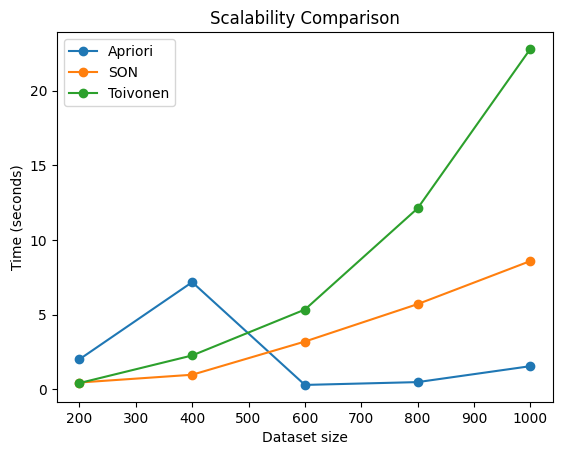

In [35]:
import matplotlib.pyplot as plt

exp2.set_index("size").plot(marker="o")
plt.title("Scalability Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Dataset size")
plt.show()

**Interpretation:**

SON and Toivonen exhibit a clear growth trend in runtime as dataset size increases, reflecting their dependence on scanning more baskets and validating candidates globally. Toivonen scales the worst because it must both sample and verify candidates against the full dataset.

On overall, SON and Toivonen remain significantly slower than Apriori across most tested sizes, since execution times are measured in seconds, the difference is substantial.

**Experiment 3 — Sampling vs Full dataset**

In [38]:
support = 0.002

# datasets
small = data_encoded.sample(frac=0.3, random_state=27)
full = data_encoded

results = []

# ---------- APRIORI ----------
start = time.time()
apriori(small, min_support=support, use_colnames=True)
results.append(("Apriori","Sample", time.time()-start))

start = time.time()
apriori(full, min_support=support, use_colnames=True)
results.append(("Apriori","Full", time.time()-start))


# ---------- SON ----------
start = time.time()
SON(small, support=support, chunks=5)
results.append(("SON","Sample", time.time()-start))

start = time.time()
SON(full, support=support, chunks=5)
results.append(("SON","Full", time.time()-start))


# ---------- TOIVONEN ----------
start = time.time()
Toivonen(small, support=support)
results.append(("Toivonen","Sample", time.time()-start))

start = time.time()
Toivonen(full, support=support)
results.append(("Toivonen","Full", time.time()-start))


# ---------- RESULT TABLE ----------
exp3=pd.DataFrame(results, columns=["Algorithm","Dataset","Time"])
exp3

,Algorithm,Dataset,Time
0,Apriori,Sample,5.166481
1,Apriori,Full,0.992488
2,SON,Sample,0.957720
3,SON,Full,9.129088
4,Toivonen,Sample,1.373237
5,Toivonen,Full,21.885645


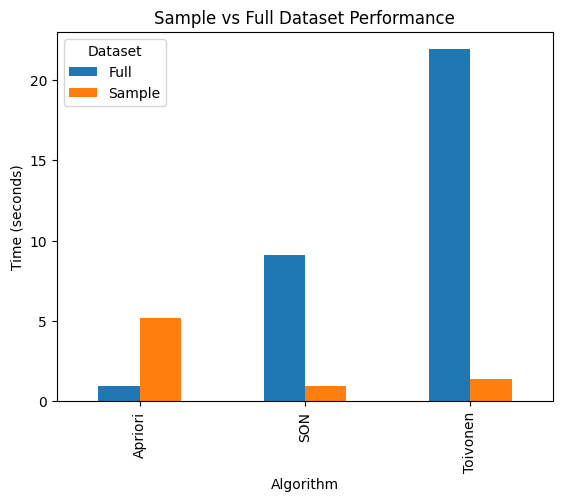

In [39]:
import matplotlib.pyplot as plt

pivot = exp3.pivot(index="Algorithm", columns="Dataset", values="Time")
pivot.plot(kind="bar")
plt.ylabel("Time (seconds)")
plt.title("Sample vs Full Dataset Performance")
plt.show()

**Interpretation:**

The experiment highlights how dataset size affects algorithm efficiency differently. Apriori ran faster on the full dataset than on the sample, which suggests internal optimizations or randomness in candidate generation affecting runtime. In contrast, SON and Toivonen behaved as expected: both were significantly faster on the sampled dataset because they processed fewer baskets. The difference is especially large for Toivonen, whose verification phase depends directly on dataset size. On overall, this experiment confirms that sampling is an effective strategy for reducing computation time, particularly for algorithms designed around sampling principles such as Toivonen that is better than A-priori.

# **Escalabilidad**

3500 max

toivonen puede 33000


In [ ]:
sizes = [4000]

datasets = {}

for s in sizes:
    multiplier = s // len(data_encoded) + 1
    datasets[s] = pd.concat([data_encoded]*multiplier).iloc[:s]

In [ ]:
import time

support = 0.002
results = []

for size, df in datasets.items():

    # APRIORI
    start = time.time()
    apriori(df, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # SON
    start = time.time()
    SON(df, support=support, chunks=5)
    t_son = time.time() - start

    # TOIVONEN
    start = time.time()
    Toivonen(df, support=support)
    t_toi = time.time() - start

    results.append((size, t_son))

scale_df = pd.DataFrame(results, columns=["size","SON"])
scale_df

error "Si è verificato un arresto anomalo della sessione a causa dell'uso di tutta la RAM disponibile." sizes = [1000, 5000, 10000, 20000]
[1000, 5000, 10000

[1000, 5000

quitar A-priori